In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1"
)

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (
        df.isnull().sum() /
        len(df)
    ) * 100
})

missing

,Missing Values,Percentage
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Customer Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0


In [8]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [9]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [10]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [11]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


In [12]:
df = df.drop_duplicates()

In [13]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


In [14]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"]
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"]
)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [16]:
text_columns = df.select_dtypes(
    include="object"
).columns

for col in text_columns:
    df[col] = df[col].str.strip()

In [17]:
summary = pd.DataFrame({

    "Column":
    df.columns,

    "Data Type":
    df.dtypes.values,

    "Missing Values":
    df.isnull().sum().values,

    "Unique Values":
    df.nunique().values

})

summary

,Column,Data Type,Missing Values,Unique Values
0,Row ID,int64,0,9994
1,Order ID,object,0,5009
2,Order Date,datetime64[ns],0,1237
3,Ship Date,datetime64[ns],0,1334
4,Ship Mode,object,0,4
5,Customer ID,object,0,793
6,Customer Name,object,0,793
7,Segment,object,0,3
8,Country,object,0,1
9,City,object,0,531


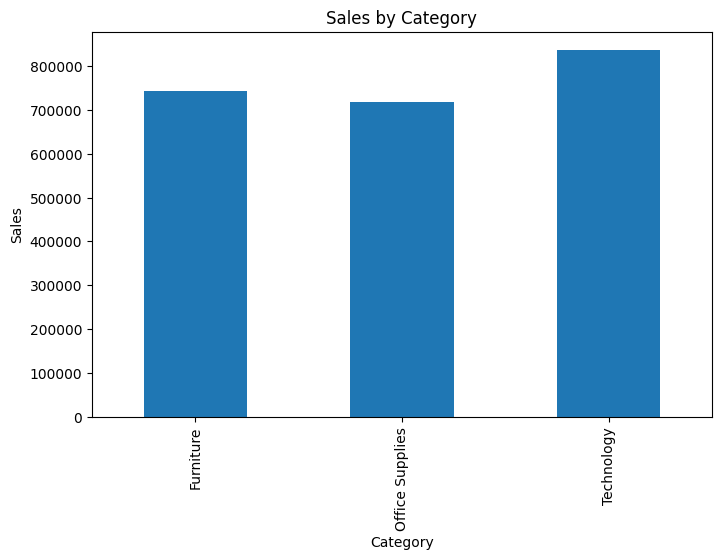

In [18]:
sales_category = df.groupby(
    "Category"
)["Sales"].sum()

sales_category.plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Category"
)

plt.ylabel("Sales")

plt.show()

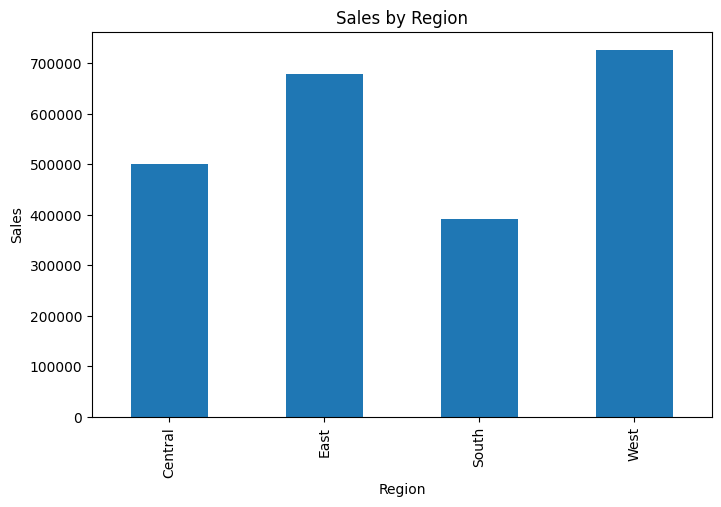

In [19]:
sales_region = df.groupby(
    "Region"
)["Sales"].sum()

sales_region.plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Region"
)

plt.ylabel("Sales")

plt.show()

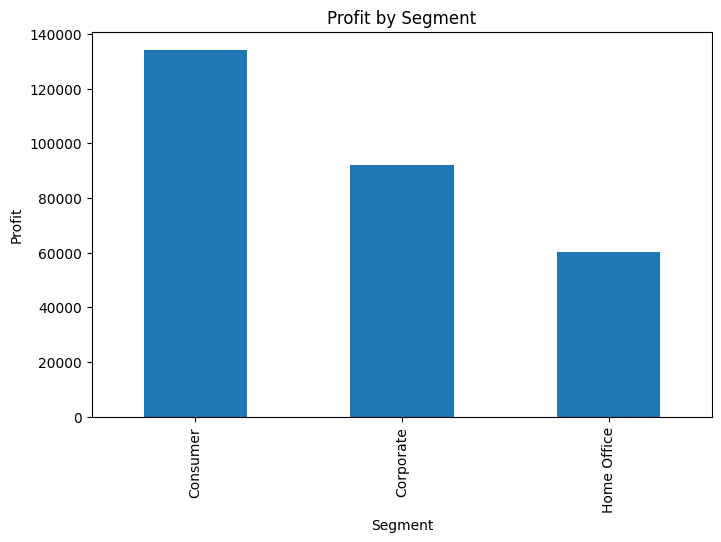

In [20]:
profit_segment = df.groupby(
    "Segment"
)["Profit"].sum()

profit_segment.plot(
    kind="bar",
    figsize=(8,5),
    title="Profit by Segment"
)

plt.ylabel("Profit")

plt.show()

In [21]:
report = {
    "Total Records": len(df),
    "Total Columns": len(df.columns),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum()
}

report

{'Total Records': 9994,
 'Total Columns': 21,
 'Missing Values': np.int64(0),
 'Duplicate Rows': np.int64(0),
 'Total Sales': np.float64(2297200.8603000003),
 'Total Profit': np.float64(286397.0217)}

In [22]:
df.to_csv(
    "Cleaned_Superstore.csv",
    index=False
)


In [23]:
summary.to_csv(
    "Data_Quality_Report.csv",
    index=False
)